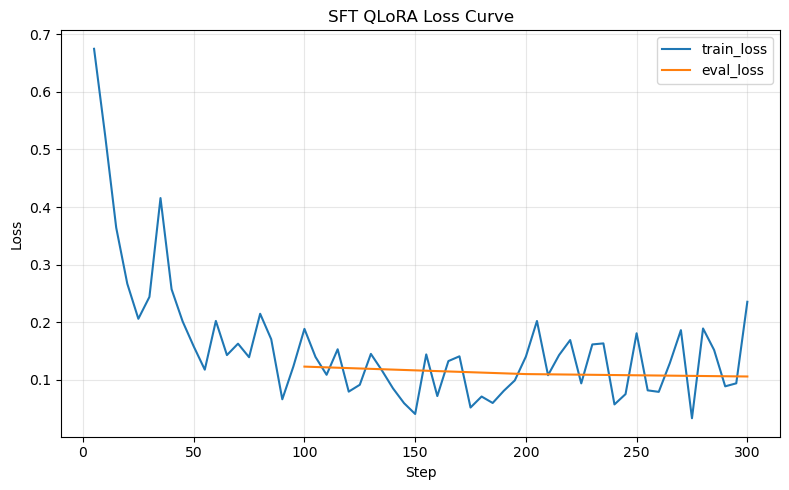

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

log_path = Path("dpo_mistral_instruct/train_log_history.jsonl")

rows = []
with log_path.open() as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

df = pd.DataFrame(rows)

train_df = df[df["loss"].notna()].copy()
eval_df = df[df["eval_loss"].notna()].copy()

plt.figure(figsize=(8, 5))
if not train_df.empty:
    plt.plot(train_df["step"], train_df["loss"], label="train_loss")
if not eval_df.empty:
    plt.plot(eval_df["step"], eval_df["eval_loss"], label="eval_loss")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("SFT QLoRA Loss Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
